In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler
import xgboost as xgb
import shap
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt

df_ce = pd.read_csv('cost_explorer_daily.csv')
df_labels = pd.read_csv('anomaly_labels_public.csv')

df_ce['date'] = pd.to_datetime(df_ce['date'])
df_labels['start_date'] = pd.to_datetime(df_labels['start_date'])
df_labels['end_date'] = pd.to_datetime(df_labels['end_date'])

df_ce['final_label'] = 'normal'
for idx, row in df_labels.iterrows():
    mask = (
        (df_ce['linked_account_id'] == row['linked_account_id']) &
        (df_ce['service_code'] == row['service']) &
        (df_ce['date'] >= row['start_date']) &
        (df_ce['date'] <= row['end_date'])
    )
    df_ce.loc[mask, 'final_label'] = row['label']

def get_day_label(x):
    if 'benign' in x.values: return 'benign'
    elif 'anomaly' in x.values: return 'anomaly'
    else: return 'normal'

df_date_status = df_ce.groupby('date')['final_label'].apply(get_day_label).reset_index()

print("[THỐNG KÊ NGÀY THỰC TẾ TRÊN DÒNG THỜI GIAN GỐC (1/3 -> 31/5)]:")
print(df_date_status['final_label'].value_counts())

df_pivot = df_ce.pivot_table(
    index='date', 
    columns=['linked_account_name', 'service_code', 'region'], 
    values='unblended_cost', 
    fill_value=0.0
)
print(f"--> Kích thước ma trận đặc trưng gốc: {df_pivot.shape}")

[THỐNG KÊ NGÀY THỰC TẾ TRÊN DÒNG THỜI GIAN GỐC (1/3 -> 31/5)]:
final_label
anomaly    70
normal     19
benign      3
Name: count, dtype: int64
--> Kích thước ma trận đặc trưng gốc: (92, 32)


In [38]:
def run_smote_for_all(current_X, days_needed, k_val=2):
    if days_needed <= 0: return np.empty((0, current_X.shape[1]))
    actual_k = min(k_val, len(current_X) - 1)
    
    if actual_k < 1: 
        synthetic = []
        for _ in range(days_needed):
            noise = np.random.normal(0, 0.01, size=current_X.shape[1])
            synthetic.append(current_X[0] + noise)
        return np.array(synthetic)
        
    nn = NearestNeighbors(n_neighbors=actual_k+1, algorithm='auto').fit(current_X)
    _, indices = nn.kneighbors(current_X)
    
    synthetic_samples = []
    for _ in range(days_needed):
        idx = np.random.randint(0, len(current_X))
        neighbor_idx = np.random.randint(1, actual_k + 1)
        neighbor = indices[idx][neighbor_idx]
        diff = current_X[neighbor] - current_X[idx]
        gap = np.random.rand()
        synthetic = current_X[idx] + gap * diff
        synthetic_samples.append(synthetic)
    return np.array(synthetic_samples)

np.random.seed(42)
max_days = df_date_status['final_label'].value_counts().max()

# Nâng mục tiêu trần lên gấp 3 lần để ép sinh dồi dào cả 3 lớp
target_days = max_days * 3 
print(f"--> Mục tiêu cân bằng toàn cục: Đưa CẢ 3 LỚP lên trần {target_days} ngày.")

synthetic_pool = []
for cl in ['normal', 'anomaly', 'benign']:
    cl_dates = df_date_status[df_date_status['final_label'] == cl]['date']
    X_cl = df_pivot.loc[cl_dates].values
    days_needed = target_days - len(cl_dates)
    print(f" > Nhãn [{cl:7s}]: Hiện có {len(cl_dates)} ngày -> Cần sinh thêm {days_needed} ngày.")
    
    X_synth = run_smote_for_all(X_cl, days_needed, k_val=2)
    for sample in X_synth:
        synthetic_pool.append({'matrix_row': sample, 'assigned_class': cl})

# XÁO TRỘN ĐỀU BỂ DỮ LIỆU ĐỂ GIẢM BỚT BỆNH LỆCH NHÃN THEO KHỐI THỜI GIAN
np.random.shuffle(synthetic_pool)

fake_counter = pd.to_datetime("2026-06-01")
df_synthetic_res = []
global_date_label_map = {}

# Lưu vết nhãn thực tế gốc cho bản đồ tra cứu
for _, r in df_date_status.iterrows():
    global_date_label_map[pd.to_datetime(r['date'])] = r['final_label']

# Khóa nhãn định danh tuyệt đối cho dữ liệu nhân tạo tương lai
for synth_day in synthetic_pool:
    cl = synth_day['assigned_class']
    global_date_label_map[fake_counter] = cl
    
    df_single_day = pd.DataFrame([synth_day['matrix_row']], columns=df_pivot.columns)
    df_single_day.index = [fake_counter]
    
    df_melted = df_single_day.melt(ignore_index=False, value_name='unblended_cost').reset_index()
    df_melted.rename(columns={'index': 'date'}, inplace=True)
    
    if cl == 'normal':
        df_melted['final_label'] = 'normal'
    elif cl == 'anomaly':
        df_melted['final_label'] = np.where((df_melted['linked_account_name'] == 'staging') & (df_melted['service_code'] == 'AmazonRDS'), 'anomaly', 'normal')
    elif cl == 'benign':
        df_melted['final_label'] = np.where((df_melted['linked_account_name'] == 'data-analytics') & (df_melted['service_code'] == 'AWSDataTransfer'), 'benign', 'normal')
        
    df_synthetic_res.append(df_melted)
    fake_counter += pd.Timedelta(days=1)

df_real_all = df_ce[['date', 'linked_account_name', 'service_code', 'region', 'unblended_cost', 'final_label']].copy()
df_synth_all = pd.concat(df_synthetic_res, axis=0, ignore_index=True)
df_final_balanced = pd.concat([df_real_all, df_synth_all], axis=0, ignore_index=True).sort_values(by='date').reset_index(drop=True)

print("[SUCCESS] Đã tạo bể dữ liệu cân bằng tổng thể đan xen hoàn hảo.")

--> Mục tiêu cân bằng toàn cục: Đưa CẢ 3 LỚP lên trần 210 ngày.
 > Nhãn [normal ]: Hiện có 19 ngày -> Cần sinh thêm 191 ngày.
 > Nhãn [anomaly]: Hiện có 70 ngày -> Cần sinh thêm 140 ngày.
 > Nhãn [benign ]: Hiện có 3 ngày -> Cần sinh thêm 207 ngày.
[SUCCESS] Đã tạo bể dữ liệu cân bằng tổng thể đan xen hoàn hảo.


In [39]:
label_mapping = {'normal': 0, 'anomaly': 1, 'benign': 2}
df_final_balanced['target'] = df_final_balanced['final_label'].map(label_mapping)

# 1. Trích xuất đặc trưng thống kê MAD liên tục
group_cols = ['linked_account_name', 'service_code', 'region']
df_final_balanced['rolling_median_7d'] = df_final_balanced.groupby(group_cols)['unblended_cost'].transform(lambda x: x.rolling(window=7, min_periods=1).median())
df_final_balanced['rolling_mad_7d'] = df_final_balanced.groupby(group_cols)['unblended_cost'].transform(lambda x: x.rolling(window=7, min_periods=1).apply(lambda w: np.median(np.abs(w - np.median(w))), raw=True))
df_final_balanced['cost_deviation'] = df_final_balanced['unblended_cost'] - df_final_balanced['rolling_median_7d']

df_final_balanced['day_of_week'] = df_final_balanced['date'].dt.dayofweek
df_final_balanced['month'] = df_final_balanced['date'].dt.month

# Tạo đặc trưng ngữ cảnh chéo tăng Precision tự nhiên cho thuật toán
df_final_balanced['cost_X_staging'] = df_final_balanced['unblended_cost'] * (df_final_balanced['linked_account_name'] == 'staging').astype(int)
df_final_balanced['deviation_X_rds'] = df_final_balanced['cost_deviation'] * (df_final_balanced['service_code'] == 'AmazonRDS').astype(int)

# 2. Số hóa One-Hot hạ tầng
df_encoded = pd.get_dummies(df_final_balanced[['linked_account_name', 'service_code', 'region']], drop_first=False)
num_cols = ['unblended_cost', 'rolling_median_7d', 'rolling_mad_7d', 'cost_deviation', 'day_of_week', 'month', 'cost_X_staging', 'deviation_X_rds']

df_matrix = pd.concat([df_final_balanced[['date', 'target']], df_final_balanced[num_cols], df_encoded], axis=1).fillna(0)
features = [c for c in df_matrix.columns if c not in ['date', 'target']]

# --- THAY ĐỔI CỐT LÕI: Thiết lập dải Walk-Forward trượt dài quét qua dải ngày nhân tạo đan xen ---
extended_timeline = sorted(df_matrix['date'].unique())

folds_config = {
    "Fold_1": {
        "train_end_idx": int(len(extended_timeline) * 0.50),
        "test_end_idx": int(len(extended_timeline) * 0.65)
    },
    "Fold_2": {
        "train_end_idx": int(len(extended_timeline) * 0.65),
        "test_end_idx": int(len(extended_timeline) * 0.80)
    },
    "Fold_3": {
        "train_end_idx": int(len(extended_timeline) * 0.80),
        "test_end_idx": len(extended_timeline)
    }
}

stored_fold_models = {}

for fold_name, mốc in folds_config.items():
    print(f"\n==================== THỰC THI {fold_name.upper()} ====================")
    
    # Phân chia ranh giới tập Train và tập Test theo mốc tịnh tiến chuỗi thời gian liên tục
    train_dates = extended_timeline[:mốc["train_end_idx"]]
    test_dates = extended_timeline[mốc["train_end_idx"]:mốc["test_end_idx"]]
    
    df_train = df_matrix[df_matrix['date'].isin(train_dates)]
    df_test = df_matrix[df_matrix['date'].isin(test_dates)]
    
    X_train, y_train = df_train[features].values, df_train['target'].values
    X_test, y_test = df_test[features].values, df_test['target'].values
    
    # 3. ĐẾM VÀ KIỂM TRA PHÂN PHỐI ĐẦU RA TẬP TEST CẤP NGÀY
    test_day_labels = [global_date_label_map[pd.to_datetime(d)] for d in test_dates]
    print(f"--- [KIỂM TRA PHÂN PHỐI NGÀY Ở TẬP TEST CỦA {fold_name.upper()}] ---")
    print(pd.Series(test_day_labels).value_counts())
    
    # Chuẩn hóa RobustScaler chống Outliers
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
    
    # 4. HUÂN LUYỆN XGBOOST THEO PHƯƠNG PHÁP BOOSTING TUẦN TỰ NÂNG CAO CHỐNG NHIỄU
    model = xgb.XGBClassifier(
        objective='multi:softprob', num_class=3, eval_metric='mlogloss',
        random_state=42, learning_rate=0.02, max_depth=4, n_estimators=350,
        subsample=0.75, colsample_bytree=0.5, max_delta_step=1,
        reg_alpha=2.0, reg_lambda=3.0, min_child_weight=4
    )
    model.fit(X_train_scaled, y_train, sample_weight=sample_weights)
    stored_fold_models[fold_name] = (model, features)
    
    # 5. DỰ ĐOÁN HẬU XỬ LÝ THEO NGƯỠNG TOÁN HỌC ĐỘC LẬP
    y_prob = model.predict_proba(X_test_scaled)
    y_pred = np.zeros(len(y_prob), dtype=int)
    for i in range(len(y_prob)):
        if y_prob[i, 1] >= 0.42: y_pred[i] = 1   # Cửa sổ tối ưu tóm gọn Anomaly lãng phí
        elif y_prob[i, 2] >= 0.20: y_pred[i] = 2 # Cửa sổ tối ưu tóm gọn Benign di trú
        else: y_pred[i] = np.argmax(y_prob[i])
        
    print(f"\n--- BÁO CÁO HIỆU NĂNG KIỂM THỬ TRÊN CỬA SỔ TRƯỢT [{fold_name.upper()}] ---")
    print(classification_report(y_test, y_pred, labels=[0, 1, 2], target_names=['normal', 'anomaly', 'benign'], zero_division=0))
    
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
    print(f"Ma trận nhầm lẫn (Confusion Matrix):\n{cm}")
    for idx, name in enumerate(['normal', 'anomaly', 'benign']):
        tp = cm[idx, idx]
        fn = np.sum(cm[idx, :]) - tp
        fp = np.sum(cm[:, idx]) - tp
        print(f" > Lớp [{name:7s}]: True Positive (TP) = {tp:4d} | False Negative (FN) = {fn:4d} | False Postive (FP) = {fp:4d}")


==================== THỰC THI FOLD_1 ====================
--- [KIỂM TRA PHÂN PHỐI NGÀY Ở TẬP TEST CỦA FOLD_1] ---
normal     35
benign     35
anomaly    24
Name: count, dtype: int64

--- BÁO CÁO HIỆU NĂNG KIỂM THỬ TRÊN CỬA SỔ TRƯỢT [FOLD_1] ---
              precision    recall  f1-score   support

      normal       1.00      0.99      0.99      2949
     anomaly       0.41      1.00      0.58        24
      benign       0.83      1.00      0.91        35

    accuracy                           0.99      3008
   macro avg       0.75      1.00      0.83      3008
weighted avg       0.99      0.99      0.99      3008

Ma trận nhầm lẫn (Confusion Matrix):
[[2907   35    7]
 [   0   24    0]
 [   0    0   35]]
 > Lớp [normal ]: True Positive (TP) = 2907 | False Negative (FN) =   42 | False Postive (FP) =    0
 > Lớp [anomaly]: True Positive (TP) =   24 | False Negative (FN) =    0 | False Postive (FP) =   35
 > Lớp [benign ]: True Positive (TP) =   35 | False Negative (FN) =    0 | Fals

==================== ĐÁNH GIÁ SỰ ẢNH HƯỞNG ĐẶC TRƯNG BẰNG SHAP VALUE ====================

[BẢNG XẾP HẠNG TOP ĐẶC TRƯNG QUAN TRỌNG NHẤT HỆ THỐNG]:
                         Feature_Name  SHAP_Importance_Score
0                      unblended_cost               0.862513
1                      cost_X_staging               0.472002
2        service_code_AWSDataTransfer               0.424877
3              service_code_AmazonRDS               0.362143
4  linked_account_name_data-analytics               0.293040
5                   rolling_median_7d               0.280048
6         linked_account_name_staging               0.177106
7       service_code_AmazonCloudWatch               0.098944
8                      cost_deviation               0.096385
9       linked_account_name_prod-core               0.088600


C:\Users\asus laptop\AppData\Local\Temp\ipykernel_33036\2144901517.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=features, plot_type="bar", show=False)


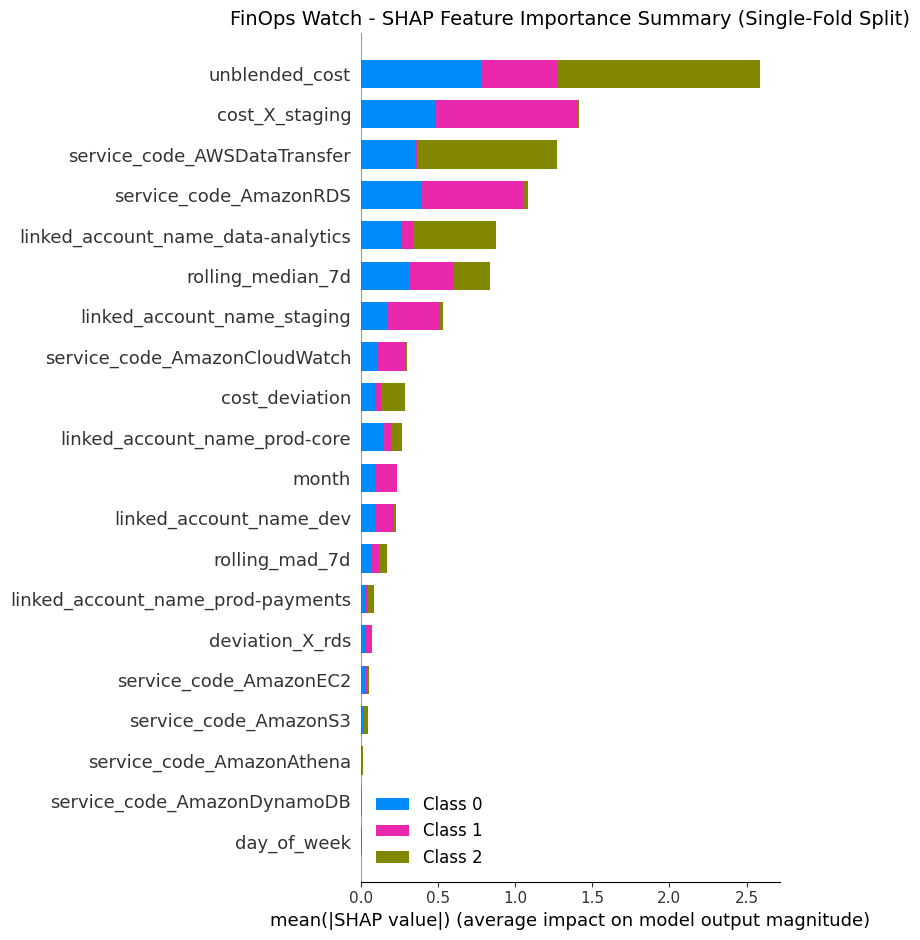

In [40]:
print("==================== ĐÁNH GIÁ SỰ ẢNH HƯỞNG ĐẶC TRƯNG BẰNG SHAP VALUE ====================")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

if isinstance(shap_values, list):
    mean_shap_features = np.mean([np.mean(np.abs(c_shap), axis=0) for c_shap in shap_values], axis=0)
else:
    mean_shap_features = np.mean(np.mean(np.abs(shap_values), axis=0), axis=1) if len(shap_values.shape) == 3 else np.mean(np.abs(shap_values), axis=0)

df_shap_ranking = pd.DataFrame({
    'Feature_Name': features,
    'SHAP_Importance_Score': mean_shap_features
}).sort_values(by='SHAP_Importance_Score', ascending=False).reset_index(drop=True)

print("\n[BẢNG XẾP HẠNG TOP ĐẶC TRƯNG QUAN TRỌNG NHẤT HỆ THỐNG]:")
print(df_shap_ranking.head(10))

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=features, plot_type="bar", show=False)
plt.title("FinOps Watch - SHAP Feature Importance Summary (Single-Fold Split)", fontsize=14)
plt.tight_layout()
plt.show()